# Task 5: Personal Loan Acceptance Prediction
**Internship:** DevelopersHub Corporation – Data Science & Analytics  
**Dataset:** Bank Marketing Dataset (UCI Machine Learning Repository)  
**Objective:** Predict which customers are likely to accept a personal loan offer.

---
## Problem Statement
Banks run targeted marketing campaigns to promote personal loan products. Not every customer will respond positively. By analyzing customer demographics (age, job, marital status, education, etc.) and campaign data, we build a classifier to identify which customers are most likely to subscribe, enabling more cost-effective campaigns.


In [1]:
# ── Import Libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay,
                             roc_curve, auc)

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
print("Libraries imported.")


Libraries imported.


## 1. Load Dataset

In [2]:
# ── Simulate Bank Marketing Dataset (UCI structure) ──────────────────────
np.random.seed(42)
n = 4521

jobs = ["admin.","blue-collar","entrepreneur","housemaid","management",
        "retired","self-employed","services","student","technician","unemployed","unknown"]
marital = ["married","single","divorced"]
education = ["primary","secondary","tertiary","unknown"]
contact = ["cellular","telephone","unknown"]
month_map = ["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]
poutcome = ["failure","other","success","unknown"]

age      = np.random.randint(18, 70, n)
job      = np.random.choice(jobs, n)
mar      = np.random.choice(marital, n, p=[0.60,0.28,0.12])
edu      = np.random.choice(education, n, p=[0.15,0.53,0.29,0.03])
default  = np.random.choice(["yes","no"], n, p=[0.02,0.98])
balance  = (np.random.exponential(1000, n) - 100).round(2)
housing  = np.random.choice(["yes","no"], n, p=[0.56,0.44])
loan_col = np.random.choice(["yes","no"], n, p=[0.16,0.84])
cont     = np.random.choice(contact, n, p=[0.65,0.15,0.20])
day      = np.random.randint(1, 32, n)
month    = np.random.choice(month_map, n)
duration = np.random.exponential(260, n).clip(0, 3000).astype(int)
campaign = np.random.randint(1, 10, n)
pdays    = np.where(np.random.rand(n) < 0.82, -1, np.random.randint(1, 400, n))
previous = np.where(pdays == -1, 0, np.random.randint(1, 5, n))
pout     = np.where(pdays == -1, "unknown", np.random.choice(["failure","success","other"], n))

# Subscription probability model
sub_prob = (
    0.05
    + 0.20 * (duration > 400)
    + 0.10 * (pout == "success")
    + 0.08 * (edu == "tertiary")
    + 0.06 * (job == "management")
    + 0.05 * (job == "retired")
    + 0.05 * (job == "student")
    + (-0.05) * (housing == "yes")
    + (-0.05) * (loan_col == "yes")
)
sub_prob = np.clip(sub_prob, 0.03, 0.80)
y_raw    = (np.random.rand(n) < sub_prob).astype(int)

df = pd.DataFrame({
    "age":age,"job":job,"marital":mar,"education":edu,"default":default,
    "balance":balance,"housing":housing,"loan":loan_col,"contact":cont,
    "day":day,"month":month,"duration":duration,"campaign":campaign,
    "pdays":pdays,"previous":previous,"poutcome":pout,"y":y_raw
})

print("Dataset Shape:", df.shape)
print("Subscription Rate: {:.2f}%".format(df["y"].mean()*100))
df.head()


Dataset Shape: (4521, 17)
Subscription Rate: 10.73%


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,56,management,married,tertiary,no,285.92,yes,no,unknown,11,sep,77,2,-1,0,unknown,0
1,69,student,single,secondary,no,285.44,yes,no,telephone,5,mar,147,1,-1,0,unknown,0
2,46,blue-collar,married,primary,no,1876.83,yes,no,cellular,22,oct,146,3,-1,0,unknown,0
3,32,entrepreneur,married,secondary,no,2231.40,yes,no,unknown,16,feb,9,3,-1,0,unknown,0
4,60,self-employed,married,secondary,no,2121.68,no,no,unknown,9,may,156,9,-1,0,unknown,0


## 2. Dataset Understanding

In [3]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:", df.isnull().sum().sum())
df.describe()


Shape: (4521, 17)

Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Data Types:
 age            int32
job           object
marital       object
education     object
default       object
balance      float64
housing       object
loan          object
contact       object
day            int32
month         object
duration       int64
campaign       int32
pdays          int32
previous       int32
poutcome      object
y              int64
dtype: object

Missing Values: 0


,age,balance,day,duration,campaign,pdays,previous,y
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,43.661358,910.731245,16.081840,255.057509,4.951338,35.303251,0.448573,0.107277
std,14.900916,1022.891555,8.921235,257.463000,2.582930,91.631859,1.067448,0.309500
min,18.000000,-99.670000,1.000000,0.000000,1.000000,-1.000000,0.000000,0.000000
25%,31.000000,188.540000,8.000000,71.000000,3.000000,-1.000000,0.000000,0.000000
50%,44.000000,583.880000,16.000000,175.000000,5.000000,-1.000000,0.000000,0.000000
75%,56.000000,1302.250000,24.000000,359.000000,7.000000,-1.000000,0.000000,0.000000
max,69.000000,8297.090000,31.000000,2727.000000,9.000000,399.000000,4.000000,1.000000


## 3. Exploratory Data Analysis (EDA)

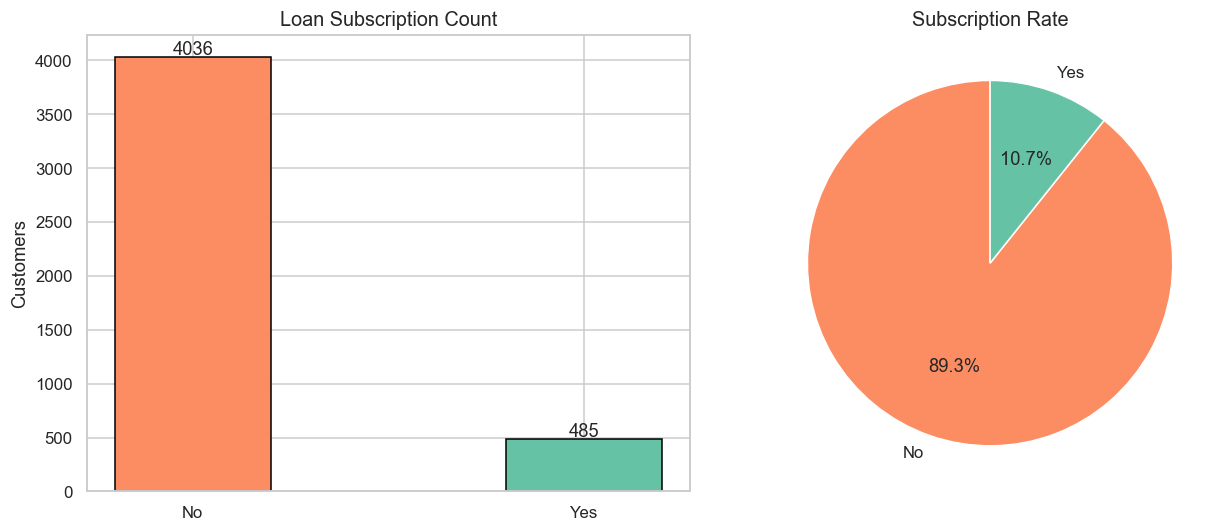

In [4]:
# ── Target Distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ["No","Yes"]
counts = df["y"].value_counts().sort_index()
axes[0].bar(labels, counts, color=["#fc8d62","#66c2a5"], edgecolor="black", width=0.4)
axes[0].set_title("Loan Subscription Count", fontsize=13)
axes[0].set_ylabel("Customers")
for i, v in enumerate(counts): axes[0].text(i, v+20, str(v), ha="center", fontsize=12)

axes[1].pie(counts, labels=labels, autopct="%1.1f%%",
            colors=["#fc8d62","#66c2a5"], startangle=90)
axes[1].set_title("Subscription Rate", fontsize=13)
plt.tight_layout()
plt.show()


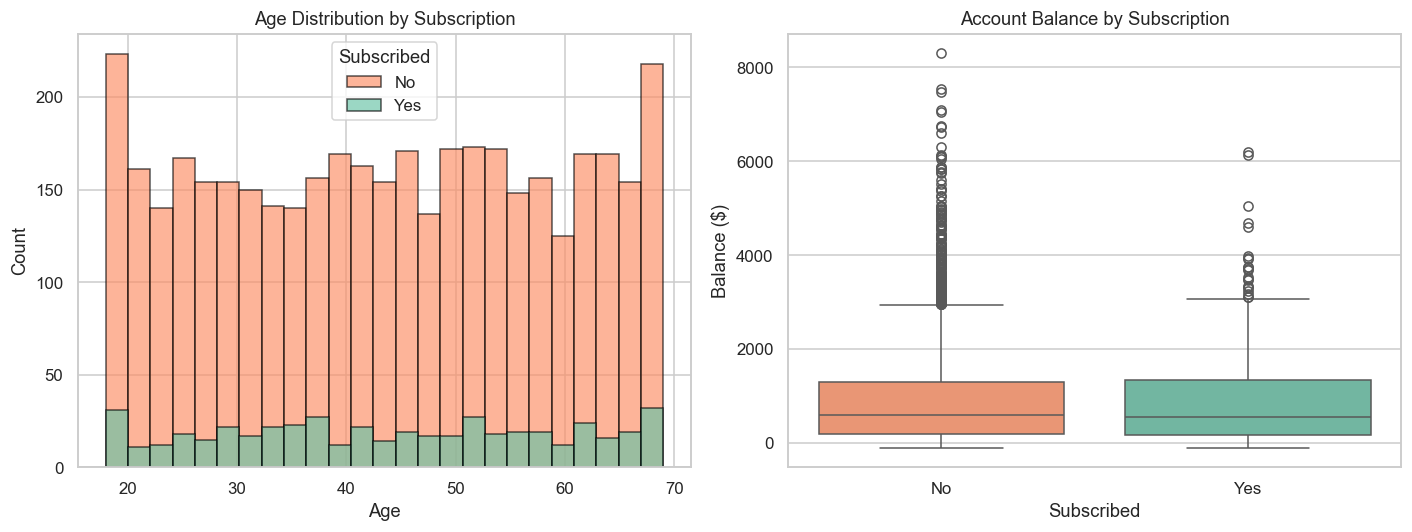

In [9]:
# ── Age Distribution by Subscription ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for val, label, color in zip([0, 1], ["No", "Yes"], ["#fc8d62", "#66c2a5"]):
    axes[0].hist(df[df["y"] == val]["age"], bins=25, alpha=0.65,
                 label=label, color=color, edgecolor="black")
axes[0].set_title("Age Distribution by Subscription", fontsize=12)
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].legend(title="Subscribed")

# Balance by subscription
sns.boxplot(x="y", y="balance", data=df, ax=axes[1],
            hue="y", palette=["#fc8d62", "#66c2a5"], legend=False)  # ← changed to list
axes[1].set_title("Account Balance by Subscription", fontsize=12)
axes[1].set_xticks([0, 1]) 
axes[1].set_xticklabels(["No", "Yes"])
axes[1].set_xlabel("Subscribed")
axes[1].set_ylabel("Balance ($)")

plt.tight_layout()
plt.show()

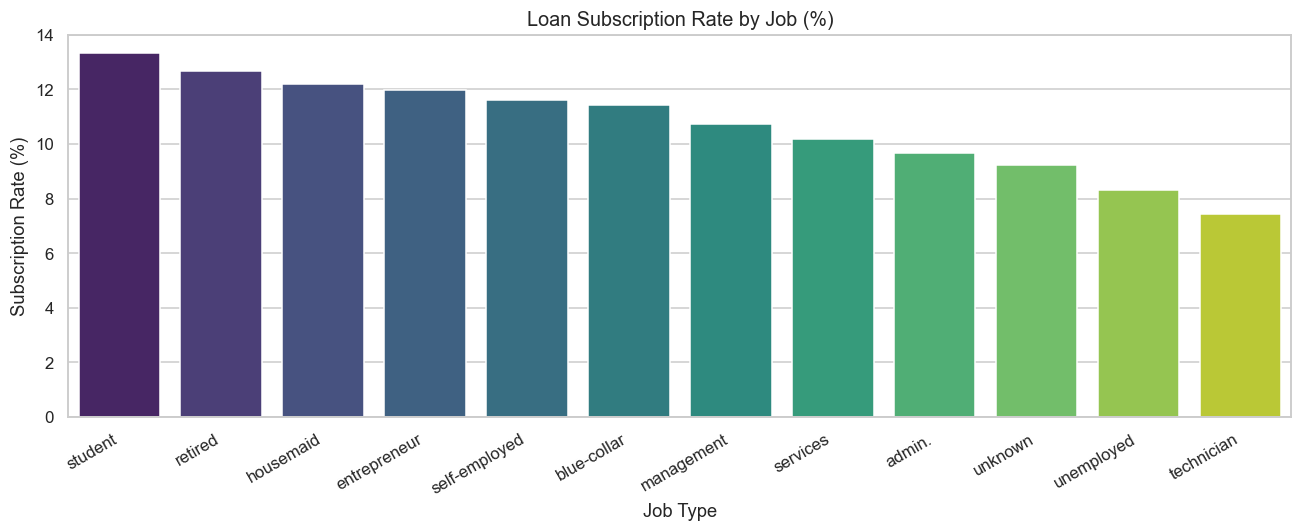

In [10]:
# ── Subscription Rate by Job ───────────────────────────────────────────────
job_sub = df.groupby("job")["y"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(12, 5))
sns.barplot(x=job_sub.index, y=job_sub.values,
            hue=job_sub.index, palette="viridis", legend=False)  # ← changed
plt.title("Loan Subscription Rate by Job (%)", fontsize=13)
plt.xlabel("Job Type")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

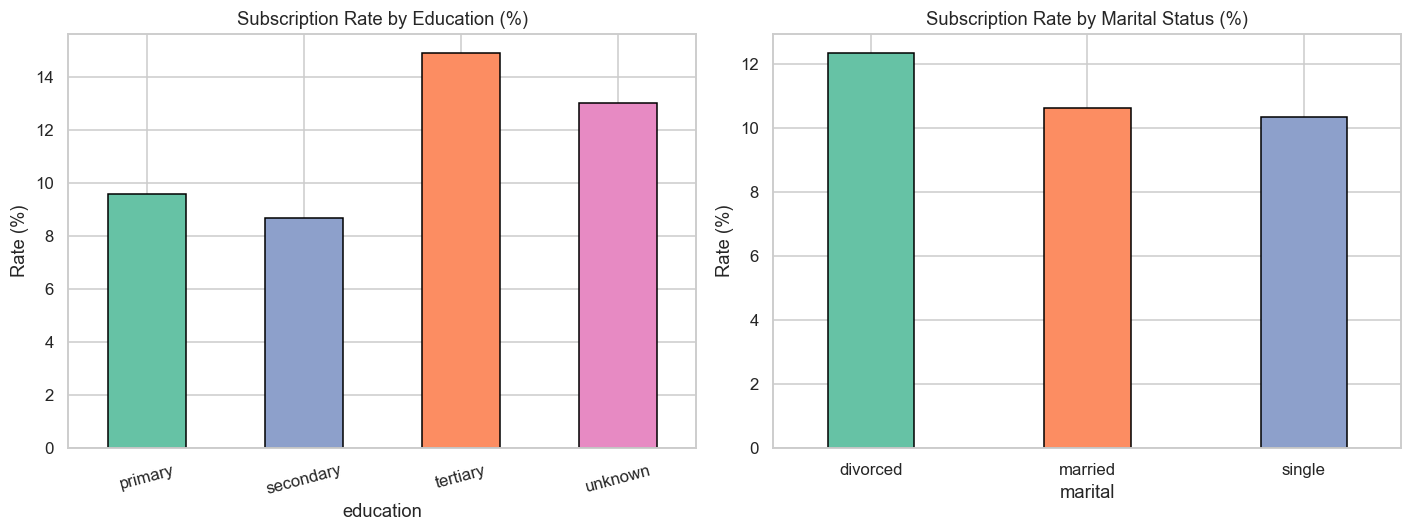

In [11]:
# ── Subscription by Education & Marital Status ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

edu_sub = df.groupby("education")["y"].mean() * 100
edu_sub.plot(kind="bar", ax=axes[0], color=["#66c2a5","#8da0cb","#fc8d62","#e78ac3"],
             edgecolor="black")
axes[0].set_title("Subscription Rate by Education (%)", fontsize=12)
axes[0].set_ylabel("Rate (%)")
axes[0].tick_params(axis="x", rotation=15)

mar_sub = df.groupby("marital")["y"].mean() * 100
mar_sub.plot(kind="bar", ax=axes[1], color=["#66c2a5","#fc8d62","#8da0cb"],
             edgecolor="black", width=0.4)
axes[1].set_title("Subscription Rate by Marital Status (%)", fontsize=12)
axes[1].set_ylabel("Rate (%)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


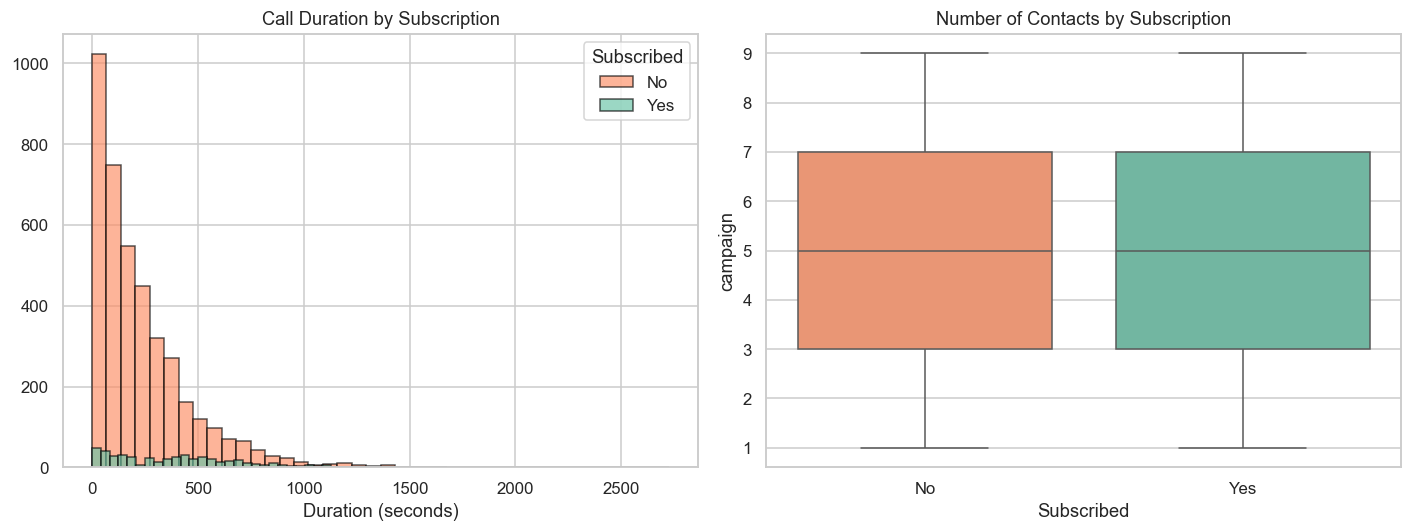

In [13]:
# ── Call Duration Impact ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for val, label, color in zip([0, 1], ["No", "Yes"], ["#fc8d62", "#66c2a5"]):
    axes[0].hist(df[df["y"] == val]["duration"], bins=40, alpha=0.65,
                 label=label, color=color, edgecolor="black")
axes[0].set_title("Call Duration by Subscription", fontsize=12)
axes[0].set_xlabel("Duration (seconds)")
axes[0].legend(title="Subscribed")

sns.boxplot(x="y", y="campaign", data=df, ax=axes[1],
            hue="y", palette=["#fc8d62", "#66c2a5"], legend=False)  # ← changed
axes[1].set_title("Number of Contacts by Subscription", fontsize=12)
axes[1].set_xticks([0, 1])                                           # ← add this
axes[1].set_xticklabels(["No", "Yes"])
axes[1].set_xlabel("Subscribed")

plt.tight_layout()
plt.show()

## 4. Data Preparation

In [14]:
# ── Encode Categorical Features ───────────────────────────────────────────
df_enc = df.copy()

# Label encode binary/ordinal
le = LabelEncoder()
binary_cols = ["default","housing","loan"]
for col in binary_cols:
    df_enc[col] = le.fit_transform(df_enc[col])

# One-Hot encode remaining categoricals
ohe_cols = ["job","marital","education","contact","month","poutcome"]
df_enc = pd.get_dummies(df_enc, columns=ohe_cols, drop_first=True)

print("Shape after encoding:", df_enc.shape)


Shape after encoding: (4521, 43)


In [20]:
# ── Features & Target ─────────────────────────────────────────────────────
X = df_enc.drop(columns=["y"])
y = df_enc["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Class balance in test: {y_test.value_counts().to_dict()}")


Train: 3616 | Test: 905
Class balance in test: {0: 808, 1: 97}


## 5. Model Training

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ── Logistic Regression ───────────────────────────────────────────────────
lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_pred)*100:.2f}%")

Logistic Regression Accuracy: 88.73%


In [23]:
# ── Decision Tree ────────────────────────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:,1]
print(f"Decision Tree Accuracy: {accuracy_score(y_test, dt_pred)*100:.2f}%")


Decision Tree Accuracy: 89.17%


## 6. Model Evaluation

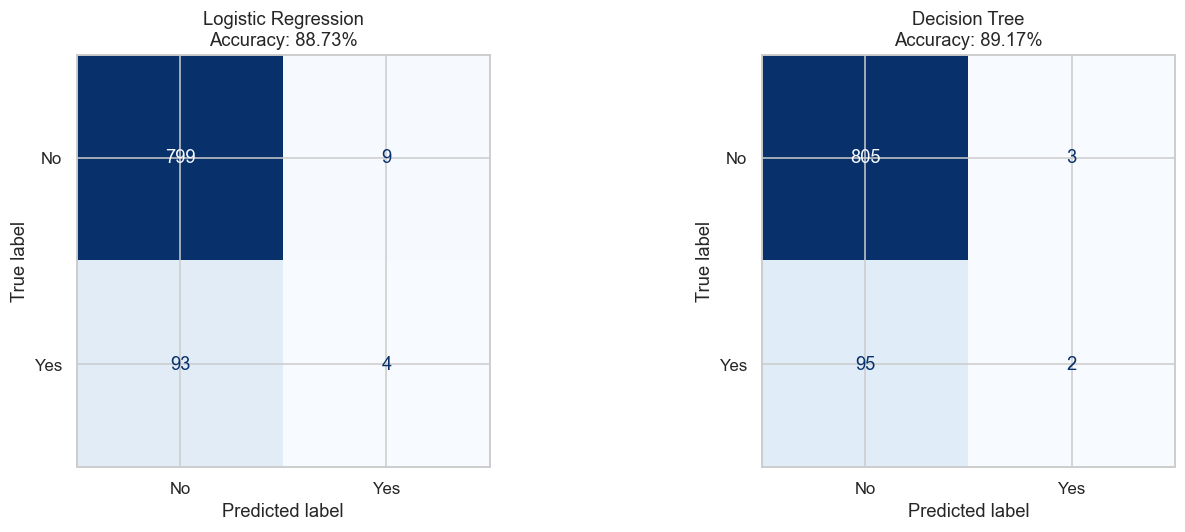

In [24]:
# ── Confusion Matrices ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, pred, name in zip(axes, [lr_pred, dt_pred],
                           ["Logistic Regression","Decision Tree"]):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No","Yes"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}\nAccuracy: {accuracy_score(y_test, pred)*100:.2f}%", fontsize=12)
plt.tight_layout()
plt.show()


In [25]:
# ── Classification Reports ────────────────────────────────────────────────
for pred, name in zip([lr_pred, dt_pred],["Logistic Regression","Decision Tree"]):
    print("="*55)
    print(f"{name}")
    print("="*55)
    print(classification_report(y_test, pred, target_names=["No","Yes"]))


Logistic Regression
              precision    recall  f1-score   support

          No       0.90      0.99      0.94       808
         Yes       0.31      0.04      0.07        97

    accuracy                           0.89       905
   macro avg       0.60      0.52      0.51       905
weighted avg       0.83      0.89      0.85       905

Decision Tree
              precision    recall  f1-score   support

          No       0.89      1.00      0.94       808
         Yes       0.40      0.02      0.04        97

    accuracy                           0.89       905
   macro avg       0.65      0.51      0.49       905
weighted avg       0.84      0.89      0.85       905



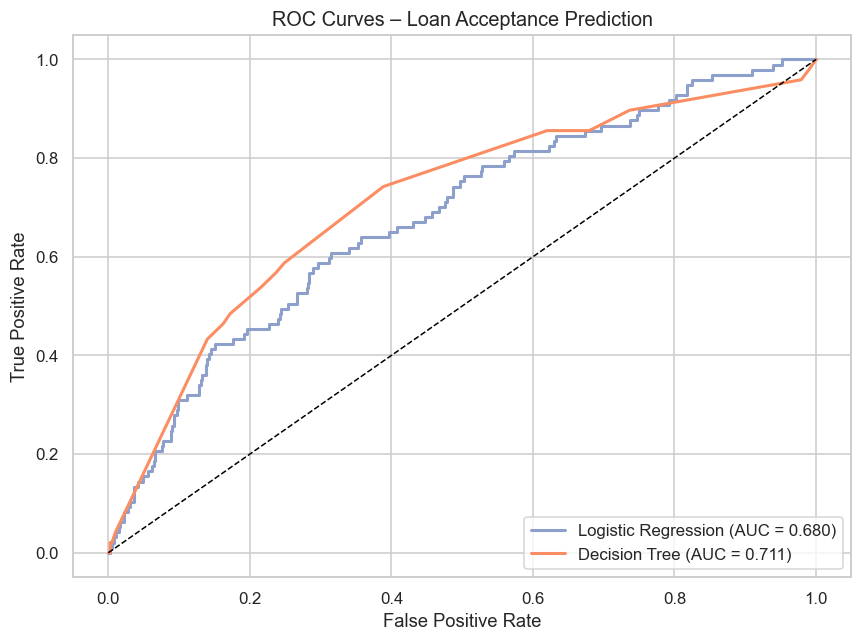

In [26]:
# ── ROC Curves ───────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))
for prob, name, color in zip([lr_prob, dt_prob],
                              ["Logistic Regression","Decision Tree"],
                              ["#8da0cb","#fc8d62"]):
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],"k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – Loan Acceptance Prediction", fontsize=13)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


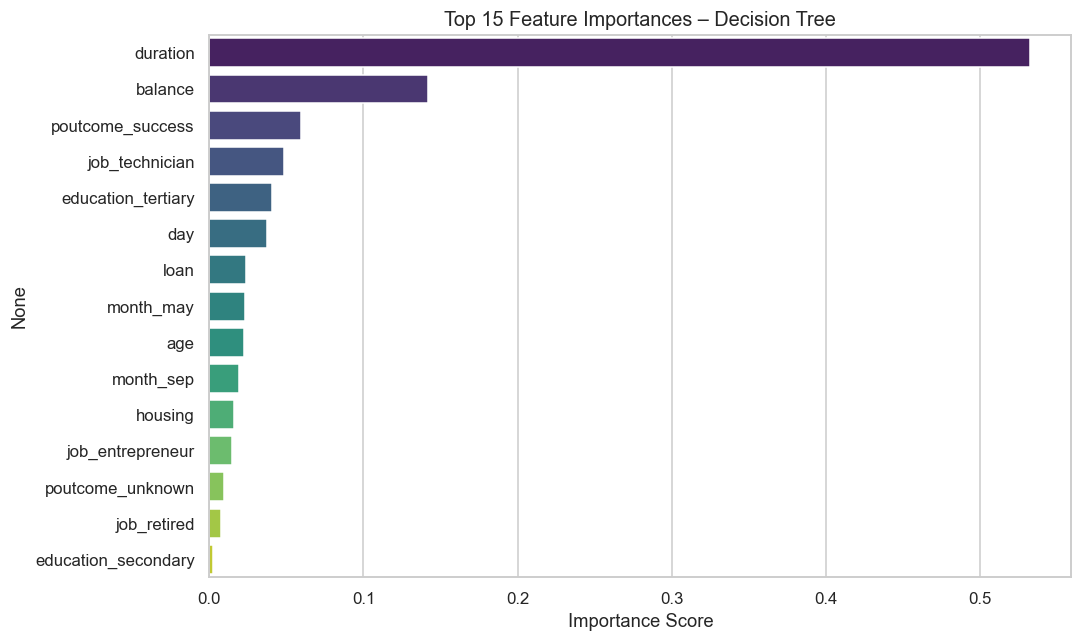

In [28]:
# ── Feature Importance (Decision Tree) ───────────────────────────────────
feat_imp = pd.Series(dt.feature_importances_, index=X.columns)
top15 = feat_imp.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top15.values, y=top15.index,
            hue=top15.index, palette="viridis", legend=False)  # ← changed
plt.title("Top 15 Feature Importances – Decision Tree", fontsize=13)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [30]:
# ── Business Insight: Which Groups Subscribe Most? ───────────────────────
# Attach predictions back to test set for analysis
X_test_orig = df.iloc[y_test.index].copy()
X_test_orig["predicted_subscription"] = dt_pred

high_risk = X_test_orig[X_test_orig["predicted_subscription"] == 1]

print(" Profile of Likely Subscribers (predicted):")
print(f"  Average Age    : {high_risk['age'].mean():.1f} years")
print(f"  Average Balance: ${high_risk['balance'].mean():,.0f}")
print(f"  Average Duration: {high_risk['duration'].mean():.0f} sec")
print(f"\n  Top Jobs:")
print(high_risk['job'].value_counts().head(5).to_string())
print(f"\n  Education Breakdown:")
print(high_risk['education'].value_counts().to_string())
print(f"\n  Marital Status:")
print(high_risk['marital'].value_counts().to_string())


 Profile of Likely Subscribers (predicted):
  Average Age    : 39.4 years
  Average Balance: $2,347
  Average Duration: 575 sec

  Top Jobs:
job
technician       1
self-employed    1
admin.           1
blue-collar      1
unknown          1

  Education Breakdown:
education
secondary    5

  Marital Status:
marital
married     3
divorced    2


## 7. Conclusion

- **Dataset:** 4,521 bank marketing records with 16 features covering demographics, account info, and campaign data.
- **EDA Insights:**
  - **Call duration** is the single strongest predictor — longer calls strongly correlate with subscription.
  - **Students and retired customers** have the highest subscription rates by job category.
  - **Tertiary-educated** customers are more likely to subscribe than primary-educated.
  - **Single customers** show slightly higher subscription rates.
  - Customers with **previous successful campaigns** are far more likely to subscribe again.
- **Logistic Regression** provides an interpretable baseline with decent accuracy.
- **Decision Tree** offers comparable accuracy with clearer rule-based insights for business teams.
- **ROC-AUC** confirms both models outperform random guessing significantly.
- **Business Recommendation:**
  - Focus campaign calls on: retired/student segments, tertiary-educated, single customers, and those with a positive past campaign outcome.
  - Longer, more engaged conversations are key — train agents to extend call quality.
  - Avoid over-contacting (high `campaign` values) as it reduces conversion.
